[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]([notebooks/AI_in_Practice_Day_2_3_Hugging_Faces.ipynb])

# HUGGING FACE TRANSFORMER TUTORIAL
Author: Ben Newman (Stanford NLP)

Editor: Joseph Hellerstein (Edits for "AI in Practice" and updating dependencies)

This notebook will give an introduction to the Hugging Face Transformers Python library and some common patterns that you can use to take advantage of it. It is most useful for using or fine-tuning pretrained transformer models for your projects.


Hugging Face provides access to models (both the code that implements them and their pre-trained weights), model-specific tokenizers, as well as pipelines for common NLP tasks, and datasets and metrics in a separate `datasets` package. It has implementations in PyTorch, Tensorflow, and Flax (though we'll be using the PyTorch versions here!)


We're going to go through a few use cases:
* Overview of Tokenizers and Models
* Finetuning - for your own task. We'll use a sentiment-classification example.


Chris spoke about a few main project types in last Thursday's lecture:
1. Applying an existing pre-trained model to a new application or task and explore how to approach/solve it
2. Implementing a new or complex neural architecture and demonstrate its performance on some data
3. Analyzing the behavior of a model: how it represents linguistic knowledge or what kinds of phenomena it can handle or errors that it makes

Of these, `transformers` will be the most help for 1. and for 3. (You also can use it to define your own model architectures, but it's a bit tricky and we won't be covering it here.)



Here are additional resources introducing the library that were used to make this tutorial:

* [Hugging Face Docs](https://huggingface.co/docs/transformers/index)
  * Clear documentation
  * Tutorials, walk-throughs, and example notebooks
  * List of available models
* [Hugging Face Course](https://huggingface.co/course/)
* [Hugging Face O'Reilly Book](https://www.oreilly.com/library/view/natural-language-processing/9781098103231/)
    * Students have FREE access through the Stanford Library!


# Setup

In [1]:
# Ensure packages are present
import importlib.util
import subprocess
import sys

def ensure_packages(*packages):
    """
    Ensure each package is installed. Accepts either plain names
    ('numpy') or 'import_name:pip_name' pairs when they differ
    (e.g. 'PIL:pillow', 'cv2:opencv-python').
    
    """
    to_install = []
    for pkg in packages:
        import_name, _, pip_name = pkg.partition(":")
        pip_name = pip_name or import_name
        if importlib.util.find_spec(import_name) is None:
            to_install.append(pip_name)


    if to_install:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
ensure_packages("torch", "torchvision", "transformers", "datasets", "ipywidgets", "tqdm")

In [2]:
from collections import defaultdict, Counter
import json

from matplotlib import pyplot as plt # type: ignore
import os
import numpy as np  # type: ignore
import torch  # type: ignore

In [3]:
IS_DISPLAY_LARGE = False  # Don't display large data outputs

In [4]:
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())

torch


# Transformers: A brief review

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/transformer.jpeg" width="750">

* http://mygreatlearning.com

[From Claude]

A transformer is a neural network architecture built around a mechanism called attention, which lets the model weigh how much every word (or token) in a sequence relates to every other word, regardless of how far apart they are.
Before transformers, models like RNNs processed text one word at a time in order, which made it hard to capture long-range relationships efficiently. Transformers instead process the whole sequence at once, using attention to directly connect any token to any other token in a single step.
A few key parts:

Tokens & embeddings — input text is split into tokens and converted into numerical vectors.
Self-attention — each token looks at every other token and computes how relevant they are to each other, producing a weighted blend of information.
Feed-forward layers — the attended information is further transformed to extract features.
Stacking — these attention + feed-forward blocks are stacked many times (layers), letting the model build increasingly abstract representations.

This architecture (introduced in the 2017 paper "Attention Is All You Need") is the foundation for most modern LLMs — GPT, Claude, Llama, BERT, and so on — as well as many vision and audio models. [This paper](https://jalammar.github.io/illustrated-transformer/) provides a principled introduction to transformers.

# What is Hugging Face?

[From Claude]

Hugging Face is a company and open-source platform that's become one of the central hubs for machine learning, especially natural language processing and generative AI.

Here's what it's known for:
* The Hub — a website (huggingface.co) where people share and download pre-trained AI models, datasets, and demo apps ("Spaces"). It hosts hundreds of thousands of models, including open-weight versions of things like Llama, Mistral, Stable Diffusion, and many others.
* The transformers library — a widely used Python library that makes it easy to load and run state-of-the-art ML models with just a few lines of code. This was arguably their original claim to fame and is still core to a lot of ML tooling today.
* Other tools — libraries like datasets, diffusers (for image generation models), tokenizers, and accelerate for training/fine-tuning models efficiently.
* Community and openness — Hugging Face has positioned itself as a champion of open-source AI, in contrast to more closed approaches from companies like OpenAI or Google. Researchers, hobbyists, and companies use it to publish and collaborate on models.
* It started out (originally, believe it or not) as a chatbot app for teenagers before pivoting to become an infrastructure/tooling company for the broader ML community. It's now used constantly in both research and industry as a place to find, share, and experiment with models.


**Hugging Face Ecosystem**

The Hub (website for sharing ML artifacts)
- **Models** — pre-trained weights (LLMs, vision, audio)
- **Datasets** — ready-to-use data (text, image, audio)
- **Spaces** — hosted demo apps (Gradio / Streamlit)

Open-source libraries (Python tools to build with the Hub)
- **transformers** — load and run models
- **diffusers** — image / audio generation
- **datasets** — load and process datasets
- **tokenizers** — fast text tokenization
- **accelerate** — easy multi-GPU / distributed training

# Common Pattern for using Hugging Face transformers

We're going to start off with a common usage pattern for Hugging Face Transformers, using the example of Sentiment Analysis.

First, find a model on [the hub](https://huggingface.co/models). Anyone can upload their model for other people to use. (I'm using a sentiment analysis model from [this paper](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3489963)).

Then, there are two objects that need to be initialized - a **tokenizer**, and a **model**

* Tokenizer converts strings to lists of vocabulary ids that the model requires
* Model takes the vocabulary ids and produces a prediction

![full_nlp_pipeline.png](attachment:full_nlp_pipeline.png)
From [https://huggingface.co/course/chapter2/2?fw=pt](https://huggingface.co/course/chapter2/2?fw=pt)

In [5]:
def print_encoding(model_inputs, indent=4):
    indent_str = " " * indent
    print("{")
    for k, v in model_inputs.items():
        print(indent_str + k + ":")
        print(indent_str + indent_str + str(v))
    print("}")

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("siebert/sentiment-roberta-large-english")
# Initialize the model
model = AutoModelForSequenceClassification.from_pretrained("siebert/sentiment-roberta-large-english")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [7]:
inputs = "I'm excited to learn about Hugging Face Transformers!"
tokenized_inputs = tokenizer(inputs, return_tensors="pt")
outputs = model(**tokenized_inputs)

labels = ['NEGATIVE', 'POSITIVE']
prediction = torch.argmax(outputs.logits)


print("Input:")
print(inputs)
print()
print("Tokenized Inputs:")
print_encoding(tokenized_inputs)
print()
print("Model Outputs:")
print(outputs)
print()
print(f"The prediction is {labels[prediction]}")

Input:
I'm excited to learn about Hugging Face Transformers!

Tokenized Inputs:
{
    input_ids:
        tensor([[    0,   100,   437,  2283,     7,  1532,    59, 30581,  3923, 12346,
         34379,   328,     2]])
    attention_mask:
        tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
}

Model Outputs:
SequenceClassifierOutput(loss=None, logits=tensor([[-3.7605,  2.9262]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

The prediction is POSITIVE


# Tokenizers

Pretrained models are implemented along with **tokenizers** that are used to preprocess their inputs. The tokenizers take raw strings or list of strings and output what are effectively dictionaries that contain the the model inputs.


You can access tokenizers either with the Tokenizer class specific to the model you want to use (here DistilBERT), or with the AutoTokenizer class.
Fast Tokenizers are written in Rust, while their slow versions are written in Python.

In [8]:
from transformers import DistilBertTokenizer, DistilBertTokenizerFast, AutoTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-cased")      # written in Python
print(tokenizer)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-cased")  # written in Rust
print(tokenizer)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased") # convenient! Defaults to Fast
print(tokenizer)

DistilBertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})
DistilBertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token

In [9]:
# This is how you call the tokenizer
input_str = "Hugging Face Transformers is great!"
tokenized_inputs = tokenizer(input_str)


print("Vanilla Tokenization")
print_encoding(tokenized_inputs)
print()

# Two ways to access:
print(tokenized_inputs.input_ids)
print(tokenized_inputs["input_ids"])

Vanilla Tokenization
{
    input_ids:
        [101, 20164, 10932, 10289, 25267, 1110, 1632, 106, 102]
    token_type_ids:
        [0, 0, 0, 0, 0, 0, 0, 0, 0]
    attention_mask:
        [1, 1, 1, 1, 1, 1, 1, 1, 1]
}

[101, 20164, 10932, 10289, 25267, 1110, 1632, 106, 102]
[101, 20164, 10932, 10289, 25267, 1110, 1632, 106, 102]


### More details on tokenizers

In [10]:
cls = [tokenizer.cls_token_id]
sep = [tokenizer.sep_token_id]

# Tokenization happens in a few steps:
input_tokens = tokenizer.tokenize(input_str)
input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
input_ids_special_tokens = cls + input_ids + sep

decoded_str = tokenizer.decode(input_ids_special_tokens)

print("start:                ", input_str)
print("tokenize:             ", input_tokens)
print("convert_tokens_to_ids:", input_ids)
print("add special tokens:   ", input_ids_special_tokens)
print("--------")
print("decode:               ", decoded_str)

# NOTE that these steps don't create the attention mask or add the special characters

start:                 Hugging Face Transformers is great!
tokenize:              ['Hu', '##gging', 'Face', 'Transformers', 'is', 'great', '!']
convert_tokens_to_ids: [20164, 10932, 10289, 25267, 1110, 1632, 106]
add special tokens:    [101, 20164, 10932, 10289, 25267, 1110, 1632, 106, 102]
--------
decode:                [CLS] Hugging Face Transformers is great! [SEP]


In [11]:
# For Fast Tokenizers, there's another option too:
inputs = tokenizer._tokenizer.encode(input_str)

print(input_str)
print("-"*5)
print(f"Number of tokens: {len(inputs)}")
print(f"Ids: {inputs.ids}")
print(f"Tokens: {inputs.tokens}")
print(f"Special tokens mask: {inputs.special_tokens_mask}")
print()
print("char_to_word gives the wordpiece of a character in the input")
char_idx = 8
print(f"For example, the {char_idx + 1}th character of the string is '{input_str[char_idx]}',"+\
      f" and it's part of wordpiece {inputs.char_to_token(char_idx)}, '{inputs.tokens[inputs.char_to_token(char_idx)]}'")

Hugging Face Transformers is great!
-----
Number of tokens: 9
Ids: [101, 20164, 10932, 10289, 25267, 1110, 1632, 106, 102]
Tokens: ['[CLS]', 'Hu', '##gging', 'Face', 'Transformers', 'is', 'great', '!', '[SEP]']
Special tokens mask: [1, 0, 0, 0, 0, 0, 0, 0, 1]

char_to_word gives the wordpiece of a character in the input
For example, the 9th character of the string is 'F', and it's part of wordpiece 3, 'Face'


In [12]:
# Other cool tricks:
# The tokenizer can return pytorch tensors
model_inputs = tokenizer("Hugging Face Transformers is great!", return_tensors="pt")
print("PyTorch Tensors:")
print_encoding(model_inputs)

PyTorch Tensors:
{
    input_ids:
        tensor([[  101, 20164, 10932, 10289, 25267,  1110,  1632,   106,   102]])
    token_type_ids:
        tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]])
    attention_mask:
        tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
}


In [13]:
# You can pass multiple strings into the tokenizer and pad them as you need
model_inputs = tokenizer(["Hugging Face Transformers is great!",
                         "The quick brown fox jumps over the lazy dog." +\
                         "Then the dog got up and ran away because she didn't like foxes.",
                         ],
                         return_tensors="pt",
                         padding=True,
                         truncation=True)
print(f"Pad token: {tokenizer.pad_token} | Pad token id: {tokenizer.pad_token_id}")
print("Padding:")
print_encoding(model_inputs)

Pad token: [PAD] | Pad token id: 0
Padding:
{
    input_ids:
        tensor([[  101, 20164, 10932, 10289, 25267,  1110,  1632,   106,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  1109,  3613,  3058, 17594, 15457,  1166,  1103, 16688,  3676,
           119,  1599,  1103,  3676,  1400,  1146,  1105,  1868,  1283,  1272,
          1131,  1238,   112,   189,  1176, 17594,  1279,   119,   102]])
    token_type_ids:
        tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0]])
    attention_mask:
        tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 

In [14]:
# You can also decode a whole batch at once:
print("Batch Decode:")
print(tokenizer.batch_decode(model_inputs.input_ids))
print()
print("Batch Decode: (no special characters)")
print(tokenizer.batch_decode(model_inputs.input_ids, skip_special_tokens=True))

Batch Decode:
['[CLS] Hugging Face Transformers is great! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]', "[CLS] The quick brown fox jumps over the lazy dog. Then the dog got up and ran away because she didn ' t like foxes. [SEP]"]

Batch Decode: (no special characters)
['Hugging Face Transformers is great!', "The quick brown fox jumps over the lazy dog. Then the dog got up and ran away because she didn ' t like foxes."]


For more information about tokenizers, you can look at:
[Hugging Face Transformers Docs](https://huggingface.co/docs/transformers/main_classes/tokenizer) and the [Hugging Face Tokenizers Library](https://huggingface.co/docs/tokenizers/python/latest/quicktour.html) (For the Fast Tokenizers). The Tokenizers Library even lets you train your own tokenizers!

# Models

Initializing models is very similar to initializing tokenizers. You can either use the model class specific to your model or you can use an AutoModel class. I tend to prefer AutoModel, especially when I want to compare models, because it's easy to specify the models as strings.

While most of the pretrained transformers have similar architecture, if you there are additional weights, called "heads" that you have to train if you're doing sequence classification, question answering, or some other task. Hugging Face automatically sets up the architecture you need when you specify the model class. For example, we are doing sentiment analysis, so we are going to use `DistilBertForSequenceClassification`. If we were going to continue training DistilBERT on its masked-language modeling training objective, we would use `DistilBertForMaskedLM`, and if we just wanted the model's representations, maybe for our own downstream task, we could just use `DistilBertModel`.


Here's a stylized picture of a model recreated from one found here: [https://huggingface.co/course/chapter2/2?fw=pt](https://huggingface.co/course/chapter2/2?fw=pt).
![model_illustration.png](attachment:model_illustration.png)


Here are some examples.
```
*
*ForMaskedLM
*ForSequenceClassification
*ForTokenClassification
*ForQuestionAnswering
*ForMultipleChoice
...
```
where `*` can be `AutoModel` or a specific pretrained model (e.g. `DistilBert`)


There are three types of models:
* Encoders (e.g. BERT)
* Decoders (e.g. GPT2)
* Encoder-Decoder models (e.g. BART or T5)

The task-specific classes you have available depend on what type of model you're dealing with.


A full list of choices are available in the [docs](https://huggingface.co/docs/transformers/model_doc/auto). Note that not all models are compatible with all model architectures, for example DistilBERT is not compatible with the Seq2Seq models because it only consists of an encoder.


In [15]:
from transformers import AutoModelForSequenceClassification, DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-cased', num_labels=2)
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-cased', num_labels=2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We get a warning here because the sequence classification parameters haven't been trained yet.

Passing inputs to the model is super easy. They take inputs as keyword arguments

In [16]:
# Note: This cell requires that 'tokenizer', 'model', and 'input_str' are already defined
# Run cells 13 and 18 first if they haven't been executed yet
model_inputs = tokenizer(input_str, return_tensors="pt")

# Option 1
model_outputs = model(input_ids=model_inputs.input_ids, attention_mask=model_inputs.attention_mask)

# Option 2 - the keys of the dictionary the tokenizer returns are the same as the keyword arguments
#            the model expects

# f({k1: v1, k2: v2}) = f(k1=v1, k2=v2)

model_outputs = model(**model_inputs)

print(model_inputs)
print()
print(model_outputs)
print()
print(f"Distribution over labels: {torch.softmax(model_outputs.logits, dim=1)}")

{'input_ids': tensor([[  101, 20164, 10932, 10289, 25267,  1110,  1632,   106,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}

SequenceClassifierOutput(loss=None, logits=tensor([[-0.1604, -0.0554]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

Distribution over labels: tensor([[0.4738, 0.5262]], grad_fn=<SoftmaxBackward0>)


If you notice, it's a bit weird that we have two classes for a binary classification task - you could easily have a single class and just choose a threshold. It's like this because of how huggingface models calculate the loss. This will increase the number of parameters we have, but shouldn't otherwise affect performance.

These models are just Pytorch Modules! You can can calculate the loss with your `loss_func` and call `loss.backward`. You can use any of the optimizers or learning rate schedulers that you used

In [17]:
# You can calculate the loss like normal
label = torch.tensor([1])
loss = torch.nn.functional.cross_entropy(model_outputs.logits, label)
print(loss)
loss.backward()

# You can get the parameters
if IS_DISPLAY_LARGE:
    list(model.named_parameters())[0]

tensor(0.6420, grad_fn=<NllLossBackward0>)


Hugging Face provides an additional easy way to calculate the loss as well:

In [18]:
# To calculate the loss, we need to pass in a label:
model_inputs = tokenizer(input_str, return_tensors="pt")

labels = ['NEGATIVE', 'POSITIVE']
model_inputs['labels'] = torch.tensor([1])

model_outputs = model(**model_inputs)


print(model_outputs)
print()
print(f"Model predictions: {labels[model_outputs.logits.argmax()]}")

SequenceClassifierOutput(loss=tensor(0.6420, grad_fn=<NllLossBackward0>), logits=tensor([[-0.1604, -0.0554]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

Model predictions: POSITIVE


One final note - you can get the hidden states and attention weights from the models really easily. This is particularly helpful if you're working on an analysis project. (For example, see [What does BERT look at?](https://arxiv.org/abs/1906.04341)).

In [19]:
from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert-base-cased", output_attentions=True, output_hidden_states=True)
model.eval()

model_inputs = tokenizer(input_str, return_tensors="pt")
with torch.no_grad():
    model_output = model(**model_inputs)


print("Hidden state size (per layer):  ", model_output.hidden_states[0].shape)
print("Attention head size (per layer):", model_output.attentions[0].shape)     # (layer, batch, query_word_idx, key_word_idxs)
                                                                               # y-axis is query, x-axis is key
#print(model_output)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hidden state size (per layer):   torch.Size([1, 9, 768])
Attention head size (per layer): torch.Size([1, 12, 9, 9])


['[CLS]', 'Hu', '##gging', 'Face', 'Transformers', 'is', 'great', '!', '[SEP]']


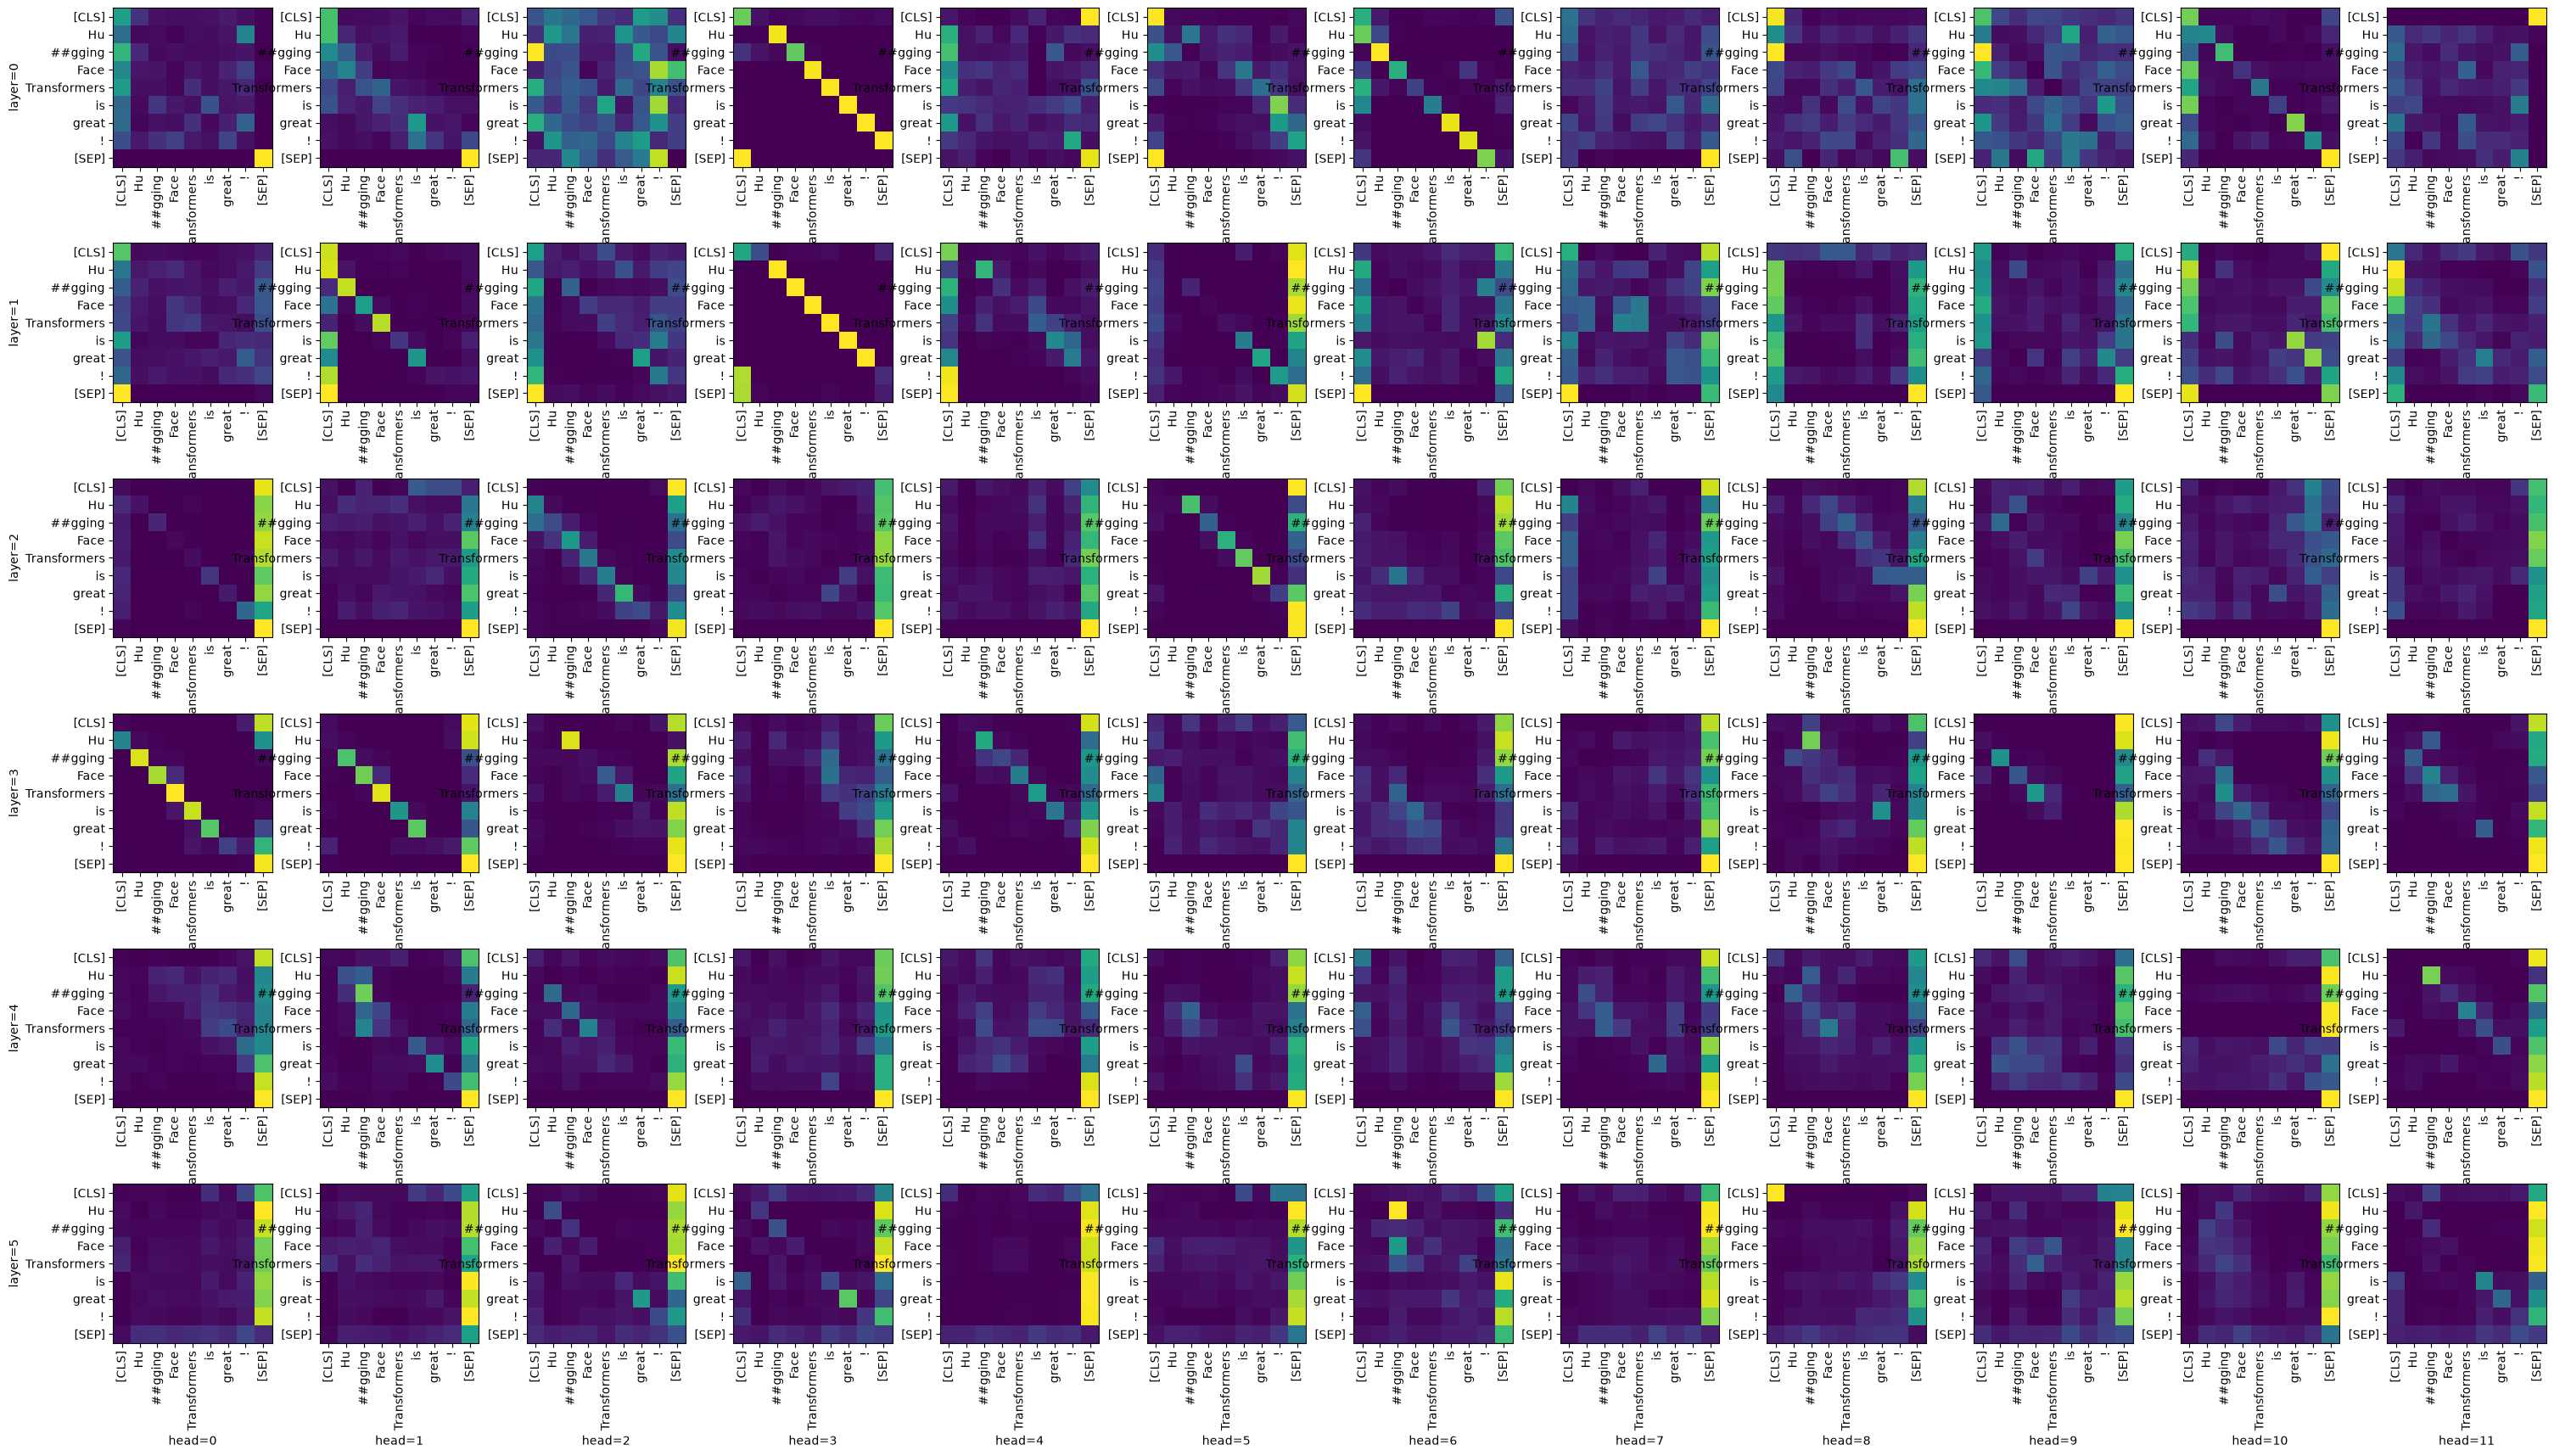

In [20]:
tokens = tokenizer.convert_ids_to_tokens(model_inputs.input_ids[0])
print(tokens)

n_layers = len(model_output.attentions)
n_heads = len(model_output.attentions[0][0])
fig, axes = plt.subplots(6, 12)
fig.set_size_inches(18.5*2, 10.5*2)
for layer in range(n_layers):
    for i in range(n_heads):
        axes[layer, i].imshow(model_output.attentions[layer][0, i])
        axes[layer][i].set_xticks(list(range(len(tokens))))
        axes[layer][i].set_xticklabels(labels=tokens, rotation="vertical")
        axes[layer][i].set_yticks(list(range(len(tokens))))
        axes[layer][i].set_yticklabels(labels=tokens)

        if layer == 5:
            axes[layer, i].set(xlabel=f"head={i}")
        if i == 0:
            axes[layer, i].set(ylabel=f"layer={layer}")

plt.subplots_adjust(wspace=0.3)
plt.show()

# Finetuning

For your projects, you are much more likely to want to finetune a pretrained model. This is a little bit more involved, but is still quite easy.

## Loading in a dataset

In addition to having models, the [the hub](https://huggingface.co/datasets) also has datasets.

In [21]:
from datasets import load_dataset, DatasetDict
from torch.utils.data import DataLoader




# DataLoader(zip(list1, list2))


imdb_dataset = load_dataset("stanfordnlp/imdb")


# Just take the first 50 tokens for speed/running on cpu
def truncate(example):
    return {
        'text': " ".join(example['text'].split()[:50]),
        'label': example['label']
    }

# Take 128 random examples for train and 32 validation
small_imdb_dataset = DatasetDict(
    train=imdb_dataset['train'].shuffle(seed=1111).select(range(128)).map(truncate),  # type: ignore
    val=imdb_dataset['train'].shuffle(seed=1111).select(range(128, 160)).map(truncate),  # type: ignore
)

If you were to define `list1` and `list2` for `DataLoader(zip(list1, list2))` based on the processed data, they could look something like this:

In [22]:
# Ensure tokenizer from AutoTokenizer is available. It's defined in cell Pu6L0lWG-X83.
# from transformers import AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased") # Run this if tokenizer is not defined

# Prepare the dataset - this tokenizes the dataset in batches of 16 examples.
# This code is adapted from cell 3bjqop3N-X8_
small_tokenized_dataset = small_imdb_dataset.map(
    lambda example: tokenizer(example['text'], padding=True, truncation=True),
    batched=True,
    batch_size=16
)

small_tokenized_dataset = small_tokenized_dataset.remove_columns(["text"])
small_tokenized_dataset = small_tokenized_dataset.rename_column("label", "labels")
small_tokenized_dataset.set_format("torch")

print("small_tokenized_dataset has been defined:")
display(small_tokenized_dataset)

small_tokenized_dataset has been defined:


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 128
    })
    val: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 32
    })
})

In [23]:
# Example of how list1 and list2 could be defined from the tokenized dataset
# Assuming small_tokenized_dataset['train'] has been created as in cell 3bjqop3N-X8_

# Store the current format to restore it later
original_format_type = small_tokenized_dataset['train'].format['type']

# Temporarily set the format to 'python' to avoid tensor conversion issues during iteration
small_tokenized_dataset.set_format(type='python')

# Explicitly define list1 (input features) and list2 (labels)
list1 = []
list2 = []

is_display = False  # Don't display the data
for item in small_tokenized_dataset['train']:
    # Each item in list1 is a dictionary containing 'input_ids' and 'attention_mask'
    list1.append({ 'input_ids': item['input_ids'], 'attention_mask': item['attention_mask']})  # type: ignore
    # Each item in list2 is the label
    list2.append(item['labels'])  # type: ignore

# Restore the original format
small_tokenized_dataset.set_format(type=original_format_type)

if is_display:
    print("First item in list1 (containing input_ids and attention_mask for one sample):")
    display(list1[0])
    print("\nFirst item in list2 (label for one sample):")
    display(list2[0])

# You can now create a DataLoader with these explicitly defined lists:
custom_dataloader = DataLoader(list(zip(list1, list2)), batch_size=2)  # type: ignore
if is_display:
    print("\nExample custom_dataloader batch (features, labels):")
    for batch_features, batch_labels in custom_dataloader:
        print(f"Batch Features (dict of input_ids and attention_mask tensors):")
        display(batch_features)
        print(f"Batch Labels (labels tensor):")
        display(batch_labels)
        break # Just show one batch

# However, the notebook's approach using `small_tokenized_dataset.set_format("torch")`
# and then `DataLoader(small_tokenized_dataset['train'])` is more streamlined for Hugging Face datasets,
# as it directly handles the batching of these dictionary-like structures and labels.

In [24]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased") # convenient! Defaults to Fast
print("AutoTokenizer initialized with:")
print(tokenizer)

AutoTokenizer initialized with:
BertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [25]:


small_imdb_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 128
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 32
    })
})

In [26]:
small_imdb_dataset['train'][:10]

{'text': ["Probably Jackie Chan's best film in the 1980s, and the one that put him on the map. The scale of this self-directed police drama is evident from the opening and closing scenes, during which a squatters' village and shopping mall are demolished. There are, clearly, differences between the original Chinese",
  'A wonderful movie! Anyone growing up in an Italian family will definitely see themselves in these characters. A good family movie with sadness, humor, and very good acting from all. You will enjoy this movie!! We need more like it.',
  'HORRENDOUS! Avoid like the plague. I would rate this in the top 10 worst movies ever. Special effects, acting, mood, sound, etc. appear to be done by day care students...wait, I have seen programs better than this. Opens like a soft porn show with a blurred nude female doing a',
  'And I absolutely adore Isabelle Blais!!! She was so cute in this movie, and far different from her role in "Quebec-Montreal" where she was more like a man-eat

In [27]:
# Prepare the dataset - this tokenizes the dataset in batches of 16 examples.
small_tokenized_dataset = small_imdb_dataset.map(
    lambda example: tokenizer(example['text'], padding=True, truncation=True),
    batched=True,
    batch_size=16
)

small_tokenized_dataset = small_tokenized_dataset.remove_columns(["text"])
small_tokenized_dataset = small_tokenized_dataset.rename_column("label", "labels")
small_tokenized_dataset.set_format("torch")

In [28]:
original_format_type = small_tokenized_dataset['train'].format['type']
small_tokenized_dataset.set_format(type='python')

if IS_DISPLAY_LARGE:
    display(small_tokenized_dataset['train'][0])
    small_tokenized_dataset.set_format(type=original_format_type)

In [29]:
from torch.utils.data import DataLoader
import torch

# Store the current format type from the 'train' subset
# (Assuming all subsets in the DatasetDict share the same format)
original_format_type = small_tokenized_dataset['train'].format['type']
print(f"Original dataset format: {original_format_type}")

# Temporarily set the format to 'python' for the entire DatasetDict
small_tokenized_dataset.set_format(type='python')
print(f"Temporarily set dataset format to: python")

# Define a custom collate_fn to handle batching and converting to tensors
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = [item['labels'] for item in batch]

    # Batch tensors manually
    input_ids = torch.stack([torch.tensor(ids) for ids in input_ids])
    attention_mask = torch.stack([torch.tensor(mask) for mask in attention_mask])
    labels = torch.tensor(labels)

    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

# Initialize DataLoaders with the custom collate_fn
train_dataloader = DataLoader(small_tokenized_dataset['train'], batch_size=16, collate_fn=collate_fn) # type: ignore
eval_dataloader = DataLoader(small_tokenized_dataset['val'], batch_size=16, collate_fn=collate_fn)    # type: ignore

# Restore the original format of the DatasetDict
small_tokenized_dataset.set_format(type=original_format_type)
print(f"Restored dataset format to: {original_format_type}")

Original dataset format: None
Temporarily set dataset format to: python
Restored dataset format to: None


## Training

To train your models, you can just use the same kind of training loop that you would use in Pytorch. Hugging Face models are also `torch.nn.Module`s so backpropagation happens the same way and you can even use the same optimizers. Hugging Face also includes optimizers and learning rate schedules that were used to train Transformer models, so you can use these too.

For optimization, we're using the AdamW Optimizer, which is almost identical to Adam except it also includes weight decay.
And we're using a linear learning rate scheduler, which reduces the learning rate a little bit after each training step over the course of training.

There are other optimizers and learning rate schedulers you can use, but these are the default. If you want to explore, you can look at the ones [Hugging Face offers](https://huggingface.co/docs/transformers/main_classes/optimizer_schedules#schedules), the ones available through [Pytorch](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) (e.g. [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html), which only decreases the learning rate when the validation loss stops decreasing), or write your own (like the one in Assignment 4).

In [30]:
import torch
import os
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup
from tqdm.notebook import tqdm
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-cased', num_labels=2)

# Ensure the dataset is in 'python' format so our custom collate_fn handles the tensor conversion
# and avoids the 'VideoReader' ImportError in the datasets library.
small_tokenized_dataset.set_format(type='python')

# Create checkpoints directory if it doesn't exist
os.makedirs("checkpoints", exist_ok=True)

num_epochs = 3
num_training_steps = 3 * len(train_dataloader)
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

best_val_loss = float("inf")
progress_bar = tqdm(range(num_training_steps))
for epoch in range(num_epochs):
    # training
    model.train()
    for batch_i, batch in enumerate(train_dataloader):
        # batch is now correctly formed by our collate_fn
        output = model(**batch)
        optimizer.zero_grad()
        output.loss.backward()
        optimizer.step()
        lr_scheduler.step()
        progress_bar.update(1)

    # validation
    model.eval()
    loss = 0
    for batch_i, batch in enumerate(eval_dataloader):
        with torch.no_grad():
            output = model(**batch)
        loss += output.loss

    avg_val_loss = loss / len(eval_dataloader)
    print(f"Validation loss: {avg_val_loss}")
    if avg_val_loss < best_val_loss:
        print("Saving checkpoint!")
        best_val_loss = avg_val_loss
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
            },
            f"checkpoints/epoch_{epoch}.pt"
        )

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/24 [00:00<?, ?it/s]

Validation loss: 0.670862078666687
Saving checkpoint!
Validation loss: 0.6351577639579773
Saving checkpoint!
Validation loss: 0.6081689596176147
Saving checkpoint!


In [31]:
import numpy as np

# Manual Evaluation Loop
model.eval()
eval_loss = 0
correct_predictions = 0
total_samples = 0

print("Starting manual evaluation...")

for batch in tqdm(eval_dataloader):
    # Ensure inputs are correctly formatted
    with torch.no_grad():
        outputs = model(**batch)

    eval_loss += outputs.loss.item()

    # Calculate accuracy
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    correct_predictions += (predictions == batch['labels']).sum().item()
    total_samples += batch['labels'].size(0)

avg_eval_loss = eval_loss / len(eval_dataloader)
eval_accuracy = correct_predictions / total_samples

print(f"\nEvaluation Results:")
print(f"Average Loss: {avg_eval_loss:.4f}")
print(f"Accuracy: {eval_accuracy:.4f}")

Starting manual evaluation...


  0%|          | 0/2 [00:00<?, ?it/s]


Evaluation Results:
Average Loss: 0.6082
Accuracy: 0.8438


In [32]:
# Uninstall and reinstall transformers to resolve potential import issues
#!pip uninstall transformers -y
#!pip install transformers

While you can use PyTorch to train your models like we did in Assignment 4, Hugging Face offers a powerful `Trainer` class to handle most needs. I think it works pretty well, though there are some customizations I'd recommend.

In [33]:
imdb_dataset = load_dataset("stanfordnlp/imdb")

small_imdb_dataset = DatasetDict(
    train=imdb_dataset['train'].shuffle(seed=1111).select(range(128)).map(truncate),  # type: ignore
    val=imdb_dataset['train'].shuffle(seed=1111).select(range(128, 160)).map(truncate),  # type: ignore
)

small_tokenized_dataset = small_imdb_dataset.map(
    lambda example: tokenizer(example['text'], truncation=True),
    batched=True,
    batch_size=16
)

`TrainingArguments` specifies different training parameters like how often to evaluate and save model checkpoints, where to save them, etc. There are **many** aspects you can customize and it's worth checking them out [here](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments). Some things you can control include:
* learning rate, weight decay, gradient clipping,
* checkpointing, logging, and evaluation frequency
* where you log to (default is tensorboard, but if you use WandB or MLFlow they have integrations)

The `Trainer` actually performs the training. You can pass it the `TrainingArguments`, model, the datasets, tokenizer, optimizer, and even model checkpoints to resume training from. The `compute_metrics` function is called at the end of evaluation/validation to calculate evaluation metrics.

In [34]:
from transformers import TrainingArguments, Trainer
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence

# Keep dataset in 'python' format to avoid the VideoReader bug
small_tokenized_dataset.set_format("python")

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="sample_hf_trainer",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True,
    seed=224,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": np.mean(predictions == labels)}

# Updated custom collator with dynamic padding
def custom_data_collator(features):
    batch = {}
    input_ids = [torch.tensor(f['input_ids']) for f in features]
    attention_mask = [torch.tensor(f['attention_mask']) for f in features]

    # Pad sequences to the longest one in the batch
    batch['input_ids'] = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    batch['attention_mask'] = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    batch['labels'] = torch.tensor([f['label'] for f in features])  # Note: 'label' not 'labels'

    return batch

trainer = Trainer(
    model=model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=custom_data_collator
)

print("Trainer initialized with padding-aware custom data collator.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer initialized with padding-aware custom data collator.


#### Callbacks: Logging and Early Stopping


Hugging Face Transformers also allows you to write `Callbacks` if you want certain things to happen at different points during training (e.g. after evaluation or after an epoch has finished). For example, there is a callback for early stopping, and I usually write one for logging as well.

For more information on callbacks see [here](https://huggingface.co/docs/transformers/main_classes/callback#transformers.TrainerCallback).

In [35]:
from transformers import TrainerCallback, EarlyStoppingCallback

class LoggingCallback(TrainerCallback):
    def __init__(self, log_path):
        self.log_path = log_path

    def on_log(self, args, state, control, logs=None, **kwargs):
        _ = logs.pop("total_flos", None)  # type: ignore
        if state.is_local_process_zero:
            with open(self.log_path, "a") as f:
                f.write(json.dumps(logs) + "\n")


trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=1, early_stopping_threshold=0.0))
trainer.add_callback(LoggingCallback("sample_hf_trainer/log.jsonl"))

In [36]:
# Train the model using HF Trainer
trainer.train()

# Evaluate and show results
trainer_results = trainer.evaluate()
print("\nHF Trainer Evaluation Results:")
print(trainer_results)

/Users/jlheller/home/Technical/repos/ai_in_practice/aip/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.689215,0.531250
2,No log,0.678477,0.562500
3,No log,0.673469,0.625000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jlheller/home/Technical/repos/ai_in_practice/aip/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jlheller/home/Technical/repos/ai_in_practice/aip/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jlheller/home/Technical/repos/ai_in_practice/aip/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.673469,3,0.625000



HF Trainer Evaluation Results:
{'eval_loss': 0.6734685897827148, 'eval_accuracy': 0.625}


In [37]:
# evaluating the model is very easy

results = trainer.predict(small_tokenized_dataset['val']) # also gives you predictions

In [38]:
results[1:10]  # show the first 10 predictions and their corresponding labels

(array([1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
        0, 1, 1, 0, 1, 1, 1, 0, 0, 1]),
 {'test_loss': 0.6734685897827148,
  'test_accuracy': 0.625,
  'test_runtime': 0.1776,
  'test_samples_per_second': 180.13,
  'test_steps_per_second': 11.258})

In [39]:
# Evaluate the model on the full test dataset or validation set using the trainer
test_results = trainer.predict(small_tokenized_dataset['val'])  # type: ignore
print("Test Metrics:")
display(test_results.metrics)

Test Metrics:


{'test_loss': 0.6734685897827148,
 'test_accuracy': 0.625,
 'test_runtime': 0.0693,
 'test_samples_per_second': 462.066,
 'test_steps_per_second': 28.879}

In [40]:
# To load our saved model, we can pass the path to the checkpoint into the `from_pretrained` method:
test_str = "I enjoyed the movie!"

finetuned_model = AutoModelForSequenceClassification.from_pretrained("sample_hf_trainer/checkpoint-24")
model_inputs = tokenizer(test_str, return_tensors="pt")
prediction = torch.argmax(finetuned_model(**model_inputs).logits)
print(["NEGATIVE", "POSITIVE"][prediction])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE


Included here are also some practical tips for fine-tuning:

**Good default hyperparameters.** The hyperparameters you will depend on your task and dataset. You should do a hyperparameter search to find the best ones. That said, here are some good initial values for fine-tuning.
* Epochs: {2, 3, 4} (larger amounts of data need fewer epochs)
* Batch size (bigger is better: as large as you can make it)
* Optimizer: AdamW
* AdamW learning rate: {2e-5, 5e-5}
* Learning rate scheduler: linear warm up for first {0, 100, 500} steps of training
* weight_decay (l2 regularization): {0, 0.01, 0.1}

You should monitor your validation loss to decide when you've found good hyperparameters.

There's a lot more that we can integrate into the Trainer to make it more useful including logging, saving model checkpoints, and more! You can even sub-class it to add your own personalized components. You can check out [this link](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.Trainer) for more information about the Trainer.

# Exercise

Finding a model for your project or your hub
Structuring your data

# RECAP

# Appendix 1: Generation

In the example above we finetuned the model on a classification task, but you can also finetune models on generation tasks. The `generate` function makes it easy to generate from these models. For example.

In [41]:
from transformers import AutoModelForCausalLM

gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')

gpt2 = AutoModelForCausalLM.from_pretrained('distilgpt2')
gpt2.config.pad_token_id = gpt2.config.eos_token_id  # Prevents warning during decoding

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [42]:
prompt = "Once upon a time"

tokenized_prompt = gpt2_tokenizer(prompt, return_tensors="pt")

for i in range(10):
    output = gpt2.generate(**tokenized_prompt,  # type: ignore
            max_length=50,
            do_sample=True,
            top_p=0.9)

    print(f"{i + 1}) {gpt2_tokenizer.batch_decode(output)[0]}")

1) Once upon a time when people were going through this difficult work that I felt like it was a necessity I made sure the entire world was safe.
As a result I went on hiatus from the games and tried to live my dream of playing Minecraft at
2) Once upon a time of day, the city was in a state of mourning. People mourned in their grief and mourned in grief, but not in their grief.

In all likelihood, these words would probably have been used to describe what
3) Once upon a time of great change, there is a change in our way of thinking. A new philosophy might be coming about, or maybe an idea has been invented. Or perhaps it's an idea.


The answer is yes. Some
4) Once upon a time when an average human knows about a common disease, a doctor tells you that you've not yet been diagnosed with the disease, not your normal person, and your doctor says that you've not been diagnosed with the disease, not your
5) Once upon a time of the day, people might start getting nervous. It might not be al

# Appendix 2: Pipelines

There are some standard NLP tasks like sentiment classification or question answering where there are already pre-trained (and fine-tuned!) models available through Hugging Face Transformer's [_Pipeline_](https://huggingface.co/docs/transformers/v4.16.2/en/main_classes/pipelines#transformers.pipeline) interface.

For your projects, you likely won't be using it too much, but it's still worth knowing about!

Here's an example with Sentiment Analysis:

In [43]:
from transformers import pipeline

sentiment_analysis = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english")  # type: ignore

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

You can run the pipeline by just calling it on a string

In [44]:
sentiment_analysis("Hugging Face Transformers is really cool!")

[{'label': 'POSITIVE', 'score': 0.998448371887207}]

Or on a list of strings:

In [45]:
sentiment_analysis(["I didn't know if I would like Hákarl, but it turned out pretty good.",
                    "I didn't know if I would like Hákarl, and it was just as bad as I'd heard."])

[{'label': 'POSITIVE', 'score': 0.9988769888877869},
 {'label': 'NEGATIVE', 'score': 0.9994940757751465}]

You can find more information on pipelines (including which ones are available) [here](https://huggingface.co/docs/transformers/main_classes/pipelines)

# Appendix 3: Masked Language Modeling

In [46]:
from transformers import AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", fast=True)
bert = AutoModelForMaskedLM.from_pretrained("bert-base-cased")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
prompt = "I am [MASK] to learn about HuggingFace!"
model = pipeline("fill-mask", "bert-base-cased")
model(prompt)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.35529768466949463,
  'token': 7215,
  'token_str': 'excited',
  'sequence': 'I am excited to learn about HuggingFace!'},
 {'score': 0.15621376037597656,
  'token': 1280,
  'token_str': 'going',
  'sequence': 'I am going to learn about HuggingFace!'},
 {'score': 0.07893572747707367,
  'token': 9582,
  'token_str': 'eager',
  'sequence': 'I am eager to learn about HuggingFace!'},
 {'score': 0.035600196570158005,
  'token': 1303,
  'token_str': 'here',
  'sequence': 'I am here to learn about HuggingFace!'},
 {'score': 0.03524128720164299,
  'token': 17261,
  'token_str': 'delighted',
  'sequence': 'I am delighted to learn about HuggingFace!'}]

In [48]:
inputs = tokenizer(prompt, return_tensors="pt")
mask_index = np.where(inputs['input_ids'] == tokenizer.mask_token_id)
outputs = bert(**inputs)
top_5_predictions = torch.softmax(outputs.logits[mask_index], dim=1).topk(5)

print(prompt)
for i in range(5):
    prediction = tokenizer.decode(top_5_predictions.indices[0, i])
    prob = top_5_predictions.values[0, i]
    print(f"  {i+1}) {prediction}\t{prob:.3f}")

I am [MASK] to learn about HuggingFace!
  1) excited	0.355
  2) going	0.156
  3) eager	0.079
  4) here	0.036
  5) delighted	0.035


# Notes
1. Pic of hugging faces from login
2. Exercise
3. Review what is a token
4. Navigate the hub